## 5. Time Series Forecasting

In this task, we implement a time series forecasting model to predict future trends in ICU patient counts. This forward-looking analysis helps anticipate healthcare demands, supporting better preparation during pandemic surges.

We use a rolling average to smooth historical trends and apply a basic forecasting approach using the Facebook Prophet model, which is well-suited for time series data with seasonality and change points.


In [16]:
import matplotlib.pyplot as plt
from prophet import Prophet
import pandas as pd

df = pd.read_csv("owid_covid_data_us_subset.csv")

# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Fill missing values
df.ffill(inplace=True)

In [17]:
# Selecting the date and the patients in the icu
df_forecast = df[['date', 'icu_patients']].rename(columns={'date': 'ds', 'icu_patients': 'y'})

# Drops missing values or zero values
df_forecast = df_forecast[df_forecast['y'] > 0]

### Creates Future DataFrame and Predicts

In [27]:
# Initialize and fit the model
model = Prophet()
model.fit(df_forecast)

# Generate 30 future days and forecast them
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Only forecast from now on
actual = df_forecast.set_index('ds')
predicted = forecast.set_index('ds')


22:48:09 - cmdstanpy - INFO - Chain [1] start processing
22:48:09 - cmdstanpy - INFO - Chain [1] done processing


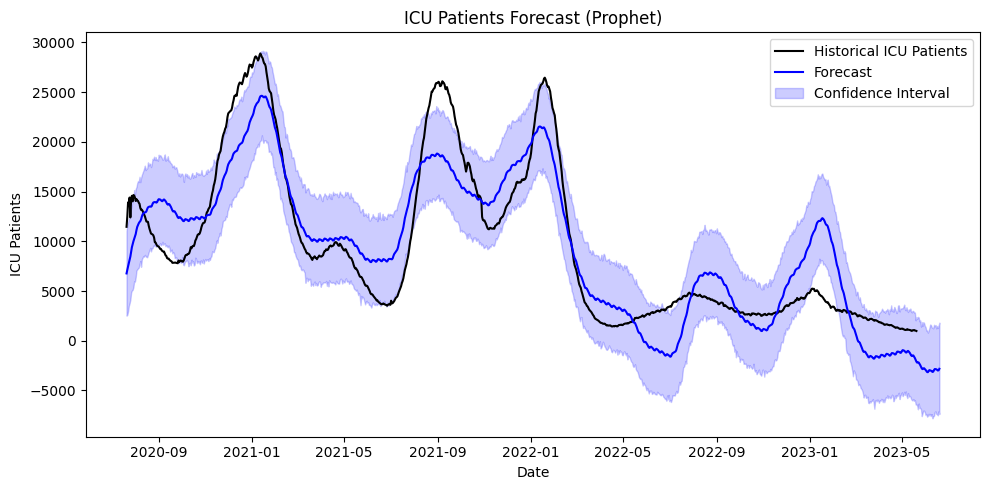

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(actual['y'], label='Historical ICU Patients', color='black')
plt.plot(predicted['yhat'], label='Forecast', color='blue')
plt.fill_between(predicted.index, predicted['yhat_lower'], predicted['yhat_upper'],
                 color='blue', alpha=0.2, label='Confidence Interval')

plt.title("ICU Patients Forecast (Prophet)")
plt.xlabel("Date")
plt.ylabel("ICU Patients")
plt.legend()
plt.tight_layout()
plt.show()

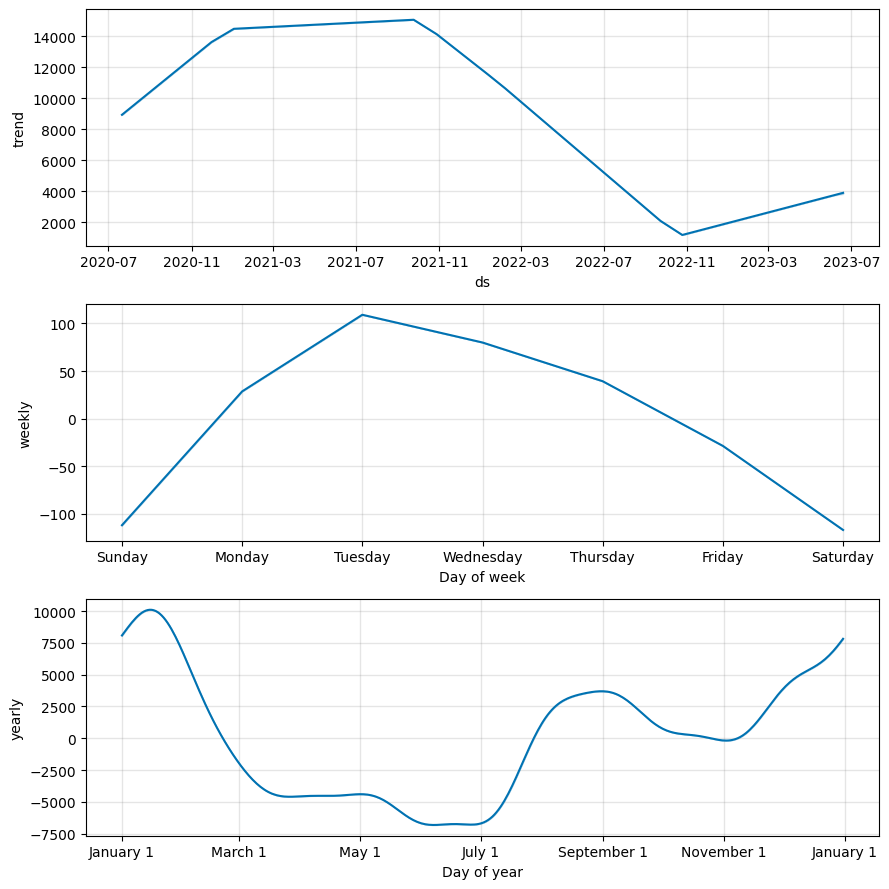

In [33]:
model.plot_components(forecast)
plt.tight_layout()
plt.show()